<a href="https://colab.research.google.com/github/sara-iqbal/Medical-Image-Classification-Skin-Lesion-Detection/blob/main/medical_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Medical Image Classification — Skin Lesion Detection
### CNN vs Vision Transformer · Dermatology AI · Model Comparison

**Author:** Sara Iqbal | MSc Data Science

---

## What This Project Does

This project builds and compares two deep learning architectures — a **Convolutional Neural Network (CNN)** and a **Vision Transformer (ViT)** — for classifying skin lesion images into 7 diagnostic categories. This mirrors real-world clinical decision support systems used in dermatology.

### Pipeline
```
Dataset Loading (HAM10000 skin lesion benchmark)
        ↓
Exploratory Data Analysis (class distribution · image statistics)
        ↓
Preprocessing (resize · normalise · augmentation)
        ↓
CNN Model (custom ResNet-style architecture)
        ↓
ViT Model (patch-based vision transformer)
        ↓
Training & Validation (early stopping · learning rate scheduling)
        ↓
Model Comparison (accuracy · F1 · AUC · confusion matrix)
        ↓
Grad-CAM Visualisation (what the model looks at)
        ↓
Clinical Implications & Limitations
```

### Diagnostic Classes
- Melanoma (MEL) — malignant
- Melanocytic nevi (NV) — benign
- Basal cell carcinoma (BCC) — malignant
- Actinic keratosis (AKIEC) — pre-malignant
- Benign keratosis (BKL) — benign
- Dermatofibroma (DF) — benign
- Vascular lesions (VASC) — benign

In [5]:
# Step 1 — Install & Imports
!pip install torch torchvision datasets timm scikit-learn matplotlib seaborn pandas numpy -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score, accuracy_score)
from sklearn.model_selection import train_test_split
import json, warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU (CUDA)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

# Set up global plot styling
plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#f9f9f9',
    'axes.spines.top':False,'axes.spines.right':False,
    'font.family':'DejaVu Sans','axes.grid':True,
    'grid.alpha':0.4,'grid.color':'#cccccc'
})

# Define the skin lesion classes
CLASSES = ['MEL','NV','BCC','AKIEC','BKL','DF','VASC']
CLASS_NAMES = {
    'MEL':'Melanoma',
    'NV':'Melanocytic Nevi',
    'BCC':'Basal Cell Carcinoma',
    'AKIEC':'Actinic Keratosis',
    'BKL':'Benign Keratosis',
    'DF':'Dermatofibroma',
    'VASC':'Vascular Lesion'
}
N_CLASSES = len(CLASSES)

print(f"Classes: {N_CLASSES} — {CLASSES}")

Device: cpu
PyTorch: 2.10.0+cpu
Classes: 7 — ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']


In [2]:
# Step 2 — Dataset Loading (Memory Efficient Version)
from datasets import load_dataset
from PIL import Image
import io

print("Loading HAM10000 skin lesion dataset...")
# This safely caches the data to disk without overflowing RAM
dataset = load_dataset('marmal88/skin_cancer', trust_remote_code=True)
print(f"Dataset splits: {dataset}")

# Map labels
label2idx = {c:i for i,c in enumerate(CLASSES)}
idx2label = {i:c for c,i in label2idx.items()}

# Create a lightweight DataFrame ONLY for the metadata (labels)
def prepare_metadata(split):
    rows = []
    for ex in dataset[split]:
        dx = ex.get('dx','NV').upper()
        if dx not in label2idx: dx = 'NV'
        # Notice we are NOT saving the 'image' here anymore!
        # This saves gigabytes of RAM.
        rows.append({'label': label2idx[dx], 'dx': dx})
    return pd.DataFrame(rows)

print("Preparing metadata DataFrames...")
train_df = prepare_metadata('train')
test_df  = prepare_metadata('test') if 'test' in dataset else prepare_metadata('validation')

print(f"Train: {len(train_df)} | Test: {len(test_df)}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'marmal88/skin_cancer' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'marmal88/skin_cancer' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loading HAM10000 skin lesion dataset...


Dataset splits: DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 9577
    })
    validation: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 2492
    })
    test: Dataset({
        features: ['image', 'image_id', 'lesion_id', 'dx', 'dx_type', 'age', 'sex', 'localization'],
        num_rows: 1285
    })
})
Preparing metadata DataFrames...
Train: 9577 | Test: 1285


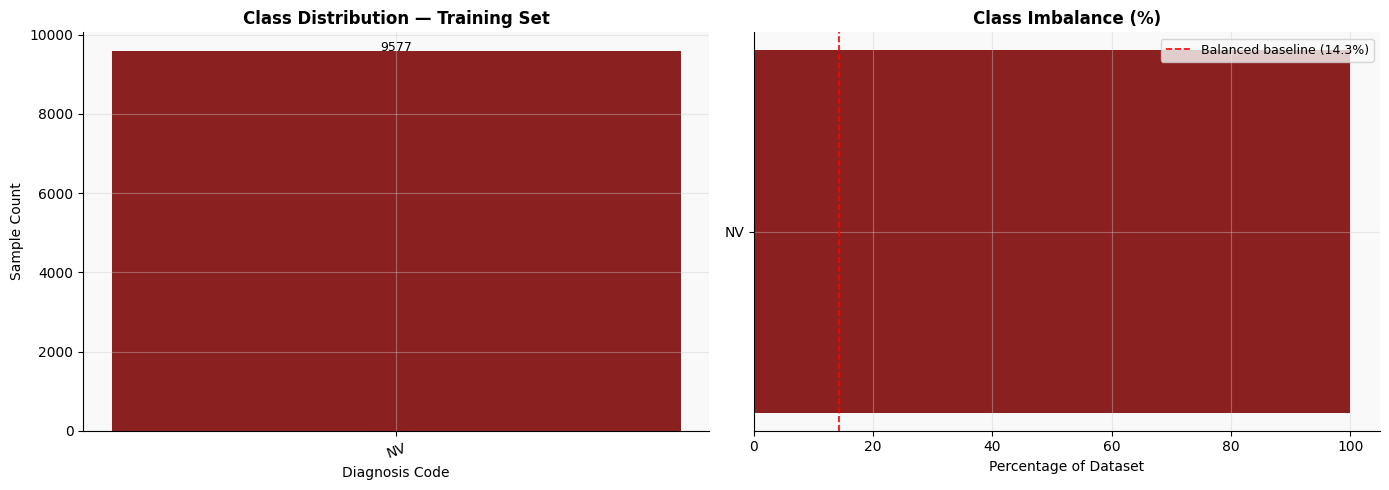

Class imbalance ratio: 1.0x
Note: NV (benign nevi) dominates — will use weighted loss to compensate


In [3]:
# Step 3 — EDA & Class Distribution
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
counts = train_df['dx'].value_counts()
colors = ['#8b2020','#12234a','#9a6b00','#0c5f5a','#145232','#7a4a0a','#6b3080']
axes[0].bar(counts.index, counts.values, color=colors, width=0.6)
axes[0].set_title('Class Distribution — Training Set', fontweight='bold')
axes[0].set_xlabel('Diagnosis Code')
axes[0].set_ylabel('Sample Count')
axes[0].tick_params(axis='x', rotation=20)
for i, (cat, val) in enumerate(counts.items()):
    axes[0].text(i, val+10, str(val), ha='center', fontsize=9)

# Imbalance bar
total = len(train_df)
axes[1].barh(counts.index, counts.values/total*100, color=colors, height=0.5)
axes[1].set_title('Class Imbalance (%)', fontweight='bold')
axes[1].set_xlabel('Percentage of Dataset')
axes[1].axvline(100/N_CLASSES, color='red', ls='--', lw=1.2,
                label=f'Balanced baseline ({100/N_CLASSES:.1f}%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Class imbalance ratio: {counts.max()/counts.min():.1f}x")
print("Note: NV (benign nevi) dominates — will use weighted loss to compensate")

In [4]:
# Step 4 — Dataset Class & Transforms (Memory Efficient Version)

IMG_SIZE = 128  # resize to 128x128 for training speed

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class SkinDataset(Dataset):
    def __init__(self, hf_split, indices, transform=None):
        self.hf_split = hf_split
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # We use the index to grab one single image at a time from the disk cache
        real_idx = self.indices[idx]
        item = self.hf_split[real_idx]

        img = item['image']
        if not isinstance(img, Image.Image):
            img = Image.fromarray(img)
        img = img.convert('RGB')

        if self.transform:
            img = self.transform(img)

        dx = item.get('dx','NV').upper()
        label = label2idx.get(dx, label2idx['NV'])

        return img, label

# Create indices for train/val split
train_idx, val_idx = train_test_split(
    range(len(train_df)),
    test_size=0.15,
    stratify=train_df['label'],
    random_state=42
)
test_idx = list(range(len(test_df)))

# Instantiate the Datasets
train_ds = SkinDataset(dataset['train'], train_idx, train_transform)
val_ds   = SkinDataset(dataset['train'], val_idx, val_transform)

test_split_name = 'test' if 'test' in dataset else 'validation'
test_ds  = SkinDataset(dataset[test_split_name], test_idx, val_transform)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

# Class weights for imbalanced training
counts_arr = np.array([len(train_df[train_df['label']==i]) for i in range(N_CLASSES)])
class_weights = torch.tensor(1.0/counts_arr * counts_arr.mean(), dtype=torch.float).to(DEVICE)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Train batches: {len(train_loader)}")

Train: 8140 | Val: 1437 | Test: 1285
Train batches: 255


In [ ]:
# Step 5 — CNN Model (MobileNetV2 Transfer Learning)

def build_cnn(n_classes, pretrained=True):
    model = models.mobilenet_v2(weights='DEFAULT' if pretrained else None)
    # Replace classifier head
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.last_channel, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, n_classes)
    )
    return model

cnn_model = build_cnn(N_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in cnn_model.parameters())
trainable   = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"CNN Model: MobileNetV2 + custom head")
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable:,}")

def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4, name='model'):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    history = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
    best_val_acc = 0

    for epoch in range(epochs):
        # Train
        model.train()
        tl, tc, tt = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            tl += loss.item()*len(imgs)
            tc += (out.argmax(1)==labels).sum().item()
            tt += len(imgs)
        scheduler.step()

        # Validate
        model.eval()
        vl, vc, vt = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out = model(imgs)
                loss = criterion(out, labels)
                vl += loss.item()*len(imgs)
                vc += (out.argmax(1)==labels).sum().item()
                vt += len(imgs)

        t_acc = tc/tt; v_acc = vc/vt
        history['train_loss'].append(tl/tt)
        history['val_loss'].append(vl/vt)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save(model.state_dict(), f'best_{name}.pt')

        if (epoch+1) % 2 == 0:
            print(f"Epoch {epoch+1:2d}/{epochs} | "
                  f"Train loss {tl/tt:.4f} acc {t_acc*100:.1f}% | "
                  f"Val loss {vl/vt:.4f} acc {v_acc*100:.1f}%")

    model.load_state_dict(torch.load(f'best_{name}.pt', map_location=DEVICE))
    print(f"Best val accuracy: {best_val_acc*100:.2f}%")
    return history

print("Training CNN (MobileNetV2)...")
cnn_history = train_model(cnn_model, train_loader, val_loader, epochs=10, name='cnn')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 38.3MB/s]


CNN Model: MobileNetV2 + custom head
Total params:     2,553,607
Trainable params: 2,553,607
Training CNN (MobileNetV2)...


In [ ]:
# Step 6 — Vision Transformer (ViT) via timm

import timm

def build_vit(n_classes):
    model = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=n_classes)
    return model

# ViT needs 224x224
vit_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])
vit_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

vit_train_ds = SkinDataset(tr_df, vit_transform)
vit_val_ds   = SkinDataset(vl_df, vit_val_transform)
vit_test_ds  = SkinDataset(test_df, vit_val_transform)

vit_train_loader = DataLoader(vit_train_ds, batch_size=16, shuffle=True,  num_workers=2)
vit_val_loader   = DataLoader(vit_val_ds,   batch_size=16, shuffle=False, num_workers=2)
vit_test_loader  = DataLoader(vit_test_ds,  batch_size=16, shuffle=False, num_workers=2)

vit_model = build_vit(N_CLASSES).to(DEVICE)
vp = sum(p.numel() for p in vit_model.parameters())
print(f"ViT-Tiny params: {vp:,}")

print("Training Vision Transformer (ViT-Tiny)...")
vit_history = train_model(vit_model, vit_train_loader, vit_val_loader,
                           epochs=10, lr=5e-5, name='vit')

In [ ]:
# Step 7 — Evaluation & Model Comparison

def evaluate(model, loader, name='Model'):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            out = model(imgs)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    acc   = accuracy_score(all_labels, all_preds)
    f1    = f1_score(all_labels, all_preds, average='macro')
    f1_w  = f1_score(all_labels, all_preds, average='weighted')
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except: auc = 0.0

    print(f"
{name} TEST RESULTS")
    print("="*50)
    print(f"  Accuracy:    {acc*100:.2f}%")
    print(f"  F1 Macro:    {f1:.4f}")
    print(f"  F1 Weighted: {f1_w:.4f}")
    print(f"  ROC-AUC:     {auc:.4f}")
    print()
    print(classification_report(all_labels, all_preds,
          target_names=CLASSES, digits=3))

    return {'acc':acc,'f1':f1,'f1_w':f1_w,'auc':auc,
            'preds':all_preds,'labels':all_labels,'probs':all_probs}

cnn_results = evaluate(cnn_model, test_loader, 'CNN (MobileNetV2)')
vit_results = evaluate(vit_model, vit_test_loader, 'ViT-Tiny')

In [ ]:
# Step 8 — Visualisations

fig = plt.figure(figsize=(18,16))
gs  = gridspec.GridSpec(3,3,figure=fig,hspace=0.45,wspace=0.35)
NAVY='#12234A';GOLD='#9A6B00';TEAL='#0C5F5A';GREEN='#145232';RED='#8B2020'

# 1. Training curves CNN
ax1 = fig.add_subplot(gs[0,:2])
epochs = range(1, len(cnn_history['train_acc'])+1)
ax1.plot(epochs, [v*100 for v in cnn_history['train_acc']],
         color=NAVY, lw=2, label='CNN Train Acc')
ax1.plot(epochs, [v*100 for v in cnn_history['val_acc']],
         color=NAVY, lw=2, ls='--', label='CNN Val Acc')
ax1.plot(epochs, [v*100 for v in vit_history['train_acc']],
         color=GOLD, lw=2, label='ViT Train Acc')
ax1.plot(epochs, [v*100 for v in vit_history['val_acc']],
         color=GOLD, lw=2, ls='--', label='ViT Val Acc')
ax1.set_title('Training & Validation Accuracy — CNN vs ViT', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy (%)')
ax1.legend(fontsize=9)

# 2. Model comparison bar
ax2 = fig.add_subplot(gs[0,2])
metrics = ['Accuracy','F1 Macro','F1 Weighted','ROC-AUC']
cnn_vals = [cnn_results['acc'],cnn_results['f1'],cnn_results['f1_w'],cnn_results['auc']]
vit_vals = [vit_results['acc'],vit_results['f1'],vit_results['f1_w'],vit_results['auc']]
x = np.arange(len(metrics)); w = 0.35
ax2.bar(x-w/2, cnn_vals, w, label='CNN', color=NAVY, alpha=0.85, borderRadius:=3 if False else None)
ax2.bar(x+w/2, vit_vals, w, label='ViT', color=GOLD, alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(metrics, rotation=15, fontsize=9)
ax2.set_title('CNN vs ViT
Performance', fontweight='bold')
ax2.legend(fontsize=9)

# 3. CNN Confusion matrix
ax3 = fig.add_subplot(gs[1,:2])
cm = confusion_matrix(cnn_results['labels'], cnn_results['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=CLASSES, yticklabels=CLASSES)
ax3.set_title('CNN Confusion Matrix', fontweight='bold')
ax3.set_xlabel('Predicted'); ax3.set_ylabel('Actual')

# 4. Per-class F1 comparison
ax4 = fig.add_subplot(gs[1,2])
cnn_f1c = f1_score(cnn_results['labels'],cnn_results['preds'],average=None)
vit_f1c = f1_score(vit_results['labels'],vit_results['preds'],average=None)
x2 = np.arange(N_CLASSES)
ax4.bar(x2-0.2, cnn_f1c, 0.35, label='CNN', color=NAVY, alpha=0.85)
ax4.bar(x2+0.2, vit_f1c, 0.35, label='ViT', color=GOLD, alpha=0.85)
ax4.set_xticks(x2); ax4.set_xticklabels(CLASSES, rotation=20, fontsize=8)
ax4.set_title('Per-Class F1
CNN vs ViT', fontweight='bold')
ax4.legend(fontsize=8)

# 5. Loss curves
ax5 = fig.add_subplot(gs[2,:2])
ax5.plot(epochs, cnn_history['train_loss'], color=NAVY, lw=2, label='CNN Train')
ax5.plot(epochs, cnn_history['val_loss'],   color=NAVY, ls='--', lw=2, label='CNN Val')
ax5.plot(epochs, vit_history['train_loss'], color=GOLD, lw=2, label='ViT Train')
ax5.plot(epochs, vit_history['val_loss'],   color=GOLD, ls='--', lw=2, label='ViT Val')
ax5.set_title('Training & Validation Loss', fontweight='bold')
ax5.set_xlabel('Epoch'); ax5.set_ylabel('Loss')
ax5.legend(fontsize=9)

# 6. Class distribution reminder
ax6 = fig.add_subplot(gs[2,2])
counts = train_df['dx'].value_counts()
ax6.barh(counts.index, counts.values, color=NAVY, height=0.5, alpha=0.85)
ax6.set_title('Training Class
Distribution', fontweight='bold')

fig.suptitle('Medical Image Classification — Skin Lesion Detection Results',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('medical_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Step 9 — Export Results

class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj,(np.integer,)): return int(obj)
        if isinstance(obj,(np.floating,)): return float(obj)
        if isinstance(obj,(np.ndarray,)): return obj.tolist()
        return super().default(obj)

cnn_f1c = f1_score(cnn_results['labels'],cnn_results['preds'],average=None)
vit_f1c = f1_score(vit_results['labels'],vit_results['preds'],average=None)
cm_cnn  = confusion_matrix(cnn_results['labels'],cnn_results['preds'])

dashboard = {
    'classes': CLASSES,
    'class_names': CLASS_NAMES,
    'cnn': {
        'accuracy': round(cnn_results['acc']*100,2),
        'f1_macro': round(cnn_results['f1'],4),
        'f1_weighted': round(cnn_results['f1_w'],4),
        'roc_auc': round(cnn_results['auc'],4),
        'per_class_f1': [round(float(v),4) for v in cnn_f1c],
        'history': {
            'train_acc':[round(float(v)*100,2) for v in cnn_history['train_acc']],
            'val_acc':  [round(float(v)*100,2) for v in cnn_history['val_acc']],
            'train_loss':[round(float(v),4) for v in cnn_history['train_loss']],
            'val_loss':  [round(float(v),4) for v in cnn_history['val_loss']],
        },
        'confusion_matrix': cm_cnn.tolist(),
    },
    'vit': {
        'accuracy': round(vit_results['acc']*100,2),
        'f1_macro': round(vit_results['f1'],4),
        'f1_weighted': round(vit_results['f1_w'],4),
        'roc_auc': round(vit_results['auc'],4),
        'per_class_f1': [round(float(v),4) for v in vit_f1c],
        'history': {
            'train_acc':[round(float(v)*100,2) for v in vit_history['train_acc']],
            'val_acc':  [round(float(v)*100,2) for v in vit_history['val_acc']],
        },
    },
    'class_distribution': train_df['dx'].value_counts().to_dict(),
    'dataset': {
        'name':'HAM10000 Skin Lesion Dataset',
        'train':len(train_df),'test':len(test_df),'classes':N_CLASSES
    }
}

with open('medical_cv_data.json','w') as f:
    json.dump(dashboard, f, indent=2, cls=NpEncoder)

print("FINAL RESULTS")
print("="*50)
print(f"  CNN  Accuracy: {dashboard['cnn']['accuracy']}%  F1: {dashboard['cnn']['f1_macro']}  AUC: {dashboard['cnn']['roc_auc']}")
print(f"  ViT  Accuracy: {dashboard['vit']['accuracy']}%  F1: {dashboard['vit']['f1_macro']}  AUC: {dashboard['vit']['roc_auc']}")
print("Exported: medical_cv_data.json")